# KUL CV GA2 - ConvNeXt Training on Colab

Self-contained Colab notebook for Section 2.1 image classification. It is meant for trying larger ConvNeXt variants or larger batch sizes than the local 8 GB RTX 4060 Laptop GPU.

Recommended first run: `convnext_small_320_colab`. Switch `EXPERIMENT_NAME` to `convnext_base_320_colab` only after Small is worth beating. `convnext_large_320_colab` is included, but only makes sense on a high-memory runtime.

Expected dataset layout after mounting Drive or uploading/extracting the data:

```text
kul-computer-vision-ga-2-2026/
  train/train_set.csv
  train/img/train_0.npy
  test/test_set.csv
  test/img/test_0.npy
```

Outputs are written to:

```text
/content/drive/MyDrive/CV-Assignment2/image_classification/<experiment>/
```

<!-- colab-cell-explain -->
## Cell 1 - Imports and GPU check

This cell imports the Python libraries used by the whole notebook: NumPy/Pandas for data, PIL/torchvision for image transforms, PyTorch for model training, scikit-learn for validation mAP, and tqdm for progress bars. It also selects `cuda` when Colab provides a GPU and prints `nvidia-smi`, so you can immediately see whether the runtime is T4, L4, A100, etc. If this cell prints CPU only, stop and enable a GPU runtime before training.


In [1]:
from pathlib import Path
import gc
import os
import random
import shutil
import subprocess
import time
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score
from tqdm.auto import tqdm

print('torch:', torch.__version__)
print('torchvision:', __import__('torchvision').__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    !nvidia-smi
    torch.backends.cudnn.benchmark = True


torch: 2.10.0+cu128
torchvision: 0.25.0+cu128
Device: cuda
GPU: Tesla T4
Sat May  9 19:47:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P0             29W /   70W |    1503MiB /  15360MiB |      0%      Default |
|                                         |                        

<!-- colab-cell-explain -->
## Cell 2 - Mount Google Drive

This cell mounts Google Drive so that checkpoints, metrics and predictions survive Colab disconnects. Keep `USE_DRIVE = True` for real experiments. Set it to `False` only for temporary smoke tests where losing outputs is acceptable.


In [3]:
# Optional: mount Google Drive for persistent data and outputs.
USE_DRIVE = True
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<!-- colab-cell-explain -->
## Cell 3 - Main configuration

This is the main control panel. Set `DATA_DIR`, `OUTPUT_ROOT`, and `EXPERIMENT_NAME` here. The `EXPERIMENTS` dictionary defines the ConvNeXt variant, image size, training batch size and evaluation batch size. For this 749-image dataset, larger batch size mainly improves throughput; it does not automatically improve generalisation. The learning rates and epoch counts at the bottom implement the same three-stage protocol used locally.


In [16]:
# Data and output configuration.
# Option A: put the unzipped dataset folder in this Drive path.
DATA_DIR = Path('/content/drive/MyDrive/CV-Assignment2/kul-computer-vision-ga-2-2026')

# Option B: upload a zip to Colab and set DATA_ZIP to it; the next cell extracts it.
DATA_ZIP = None  # Example: Path('/content/kul-computer-vision-ga-2-2026.zip')

OUTPUT_ROOT = Path('/content/drive/MyDrive/CV-Assignment2/image_classification') if USE_DRIVE else Path('/content/image_classification')

# Choose one: convnext_tiny_320_colab, convnext_small_320_colab, convnext_base_320_colab, convnext_large_320_colab
EXPERIMENT_NAME = 'convnext_base_320_colab'

LABELS = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person',
    'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor',
]

EXPERIMENTS = {
    # Conservative defaults that fit common 16 GB Colab GPUs. Increase batch sizes on A100/L4 if memory is comfortable.
    'convnext_tiny_320_colab':  dict(backbone='convnext_tiny',  img_size=320, batch_size=32, eval_batch_size=64),
    'convnext_small_320_colab': dict(backbone='convnext_small', img_size=320, batch_size=16, eval_batch_size=32),
    'convnext_base_320_colab':  dict(backbone='convnext_base',  img_size=320, batch_size=8,  eval_batch_size=16),
    'convnext_large_320_colab': dict(backbone='convnext_large', img_size=320, batch_size=4,  eval_batch_size=8),
}

CFG = EXPERIMENTS[EXPERIMENT_NAME]
BACKBONE = CFG['backbone']
IMG_SIZE = CFG['img_size']
BATCH_SIZE = CFG['batch_size']
EVAL_BATCH_SIZE = CFG['eval_batch_size']
NUM_WORKERS = 2
VAL_SPLIT = 0.2
RANDOM_SEED = 42
WEIGHT_DECAY = 1e-4
USE_AMP = True

# For quick smoke tests, set smaller epochs. For final experiments, keep the local protocol.
STAGE1_EPOCHS, STAGE1_LR = 5, 1e-3
STAGE2_EPOCHS, STAGE2_LR = 20, 1e-4
STAGE3_EPOCHS, STAGE3_LR = 5, 5e-5

OUTPUT_DIR = OUTPUT_ROOT / EXPERIMENT_NAME
CHECKPOINT_DIR = OUTPUT_DIR / 'checkpoints'
METRICS_DIR = OUTPUT_DIR / 'metrics'
FIGURES_DIR = OUTPUT_DIR / 'figures'
PREDICTIONS_DIR = OUTPUT_DIR / 'predictions'
SUBMISSIONS_DIR = OUTPUT_DIR / 'submissions'
for directory in (CHECKPOINT_DIR, METRICS_DIR, FIGURES_DIR, PREDICTIONS_DIR, SUBMISSIONS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

BEST_CKPT = CHECKPOINT_DIR / 'best_model.pth'
LAST_CKPT = CHECKPOINT_DIR / 'last_model.pth'
FINAL_CKPT = CHECKPOINT_DIR / 'final_model.pth'
THRESHOLDS_PATH = METRICS_DIR / 'best_thresholds.npy'
AP_CSV = METRICS_DIR / 'ap_per_class.csv'
SUMMARY_CSV = METRICS_DIR / 'evaluation_summary.csv'
HISTORY_CSV = METRICS_DIR / 'training_history.csv'
AP_PLOT = FIGURES_DIR / 'eval_ap_per_class.png'
HISTORY_PLOT = FIGURES_DIR / 'training_history.png'
PROBABILITY_CSV = PREDICTIONS_DIR / f'test_probabilities_{EXPERIMENT_NAME}.csv'
BINARY_PREDICTION_CSV = PREDICTIONS_DIR / f'test_binary_predictions_{EXPERIMENT_NAME}.csv'
SUBMISSION_CSV = SUBMISSIONS_DIR / f'submission_classification_{EXPERIMENT_NAME}.csv'

print('Experiment:', EXPERIMENT_NAME)
print('Backbone:', BACKBONE)
print('Batch size:', BATCH_SIZE, 'Eval batch size:', EVAL_BATCH_SIZE)
print('Data dir:', DATA_DIR)
print('Output dir:', OUTPUT_DIR)


Experiment: convnext_base_320_colab
Backbone: convnext_base
Batch size: 8 Eval batch size: 16
Data dir: /content/drive/MyDrive/CV-Assignment2/kul-computer-vision-ga-2-2026
Output dir: /content/drive/MyDrive/CV-Assignment2/image_classification/convnext_base_320_colab


<!-- colab-cell-explain -->
## Cell 3b - Plotting helpers

These helpers turn the saved metric tables into PNG figures. They are intentionally separate from training/evaluation, so you can regenerate figures later from existing CSV files without spending GPU time again.


In [17]:
def plot_training_history(history_df, output_path):
    history_df = history_df.copy()
    if history_df.empty:
        print('No training history rows to plot.')
        return

    history_df['step'] = np.arange(1, len(history_df) + 1)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(history_df['step'], history_df['train_loss'], marker='o', linewidth=1.8, label='train loss')

    val_df = history_df.dropna(subset=['val_loss'])
    if not val_df.empty:
        ax.plot(val_df['step'], val_df['val_loss'], marker='s', linewidth=1.8, label='val loss')

    stage_starts = history_df.groupby('stage', sort=False)['step'].min()
    ymax = float(np.nanmax(history_df[['train_loss', 'val_loss']].to_numpy()))
    for stage, start in stage_starts.items():
        ax.axvline(start, color='0.85', linewidth=0.8, zorder=0)
        ax.text(start, ymax, stage, va='top', ha='left', fontsize=9, color='0.35')

    ax.set_title(f'{EXPERIMENT_NAME} training history')
    ax.set_xlabel('training step (epoch within each stage)')
    ax.set_ylabel('AsymmetricLoss')
    ax.grid(True, alpha=0.25)
    ax.legend()
    fig.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=140)
    plt.close(fig)
    print('Saved figure:', output_path)


def plot_ap_per_class(ap_df, output_path, map_score=None):
    if ap_df.empty:
        print('No AP rows to plot.')
        return

    plot_df = ap_df.copy()
    if 'class' in plot_df.columns:
        plot_df['class'] = pd.Categorical(plot_df['class'], categories=LABELS, ordered=True)
        plot_df = plot_df.sort_values('class')

    map_value = float(map_score) if map_score is not None else float(plot_df['ap'].mean())
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(plot_df['class'].astype(str), plot_df['ap'], color='#4c86b7')
    ax.axhline(map_value, color='red', linestyle='--', linewidth=1.4, label=f'mAP={map_value:.3f}')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Average Precision')
    ax.set_title(f'Per-class AP on validation set ({EXPERIMENT_NAME})')
    ax.tick_params(axis='x', rotation=45)
    for tick in ax.get_xticklabels():
        tick.set_ha('right')
    ax.legend(loc='upper center')
    fig.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=140)
    plt.close(fig)
    print('Saved figure:', output_path)


<!-- colab-cell-explain -->
## Cell 4 - Dataset layout check

This cell optionally extracts a zip file and then verifies that the dataset has the expected Kaggle folder structure. It fails early if `train_set.csv`, `test_set.csv`, or the image folders are missing. Run this before training so path mistakes do not waste GPU time.


In [18]:
# Extract uploaded zip if needed, then verify dataset layout.
if DATA_ZIP is not None:
    DATA_ZIP = Path(DATA_ZIP)
    extract_root = Path('/content')
    print('Extracting', DATA_ZIP, 'to', extract_root)
    with zipfile.ZipFile(DATA_ZIP, 'r') as zf:
        zf.extractall(extract_root)
    if not DATA_DIR.exists():
        candidates = list(extract_root.glob('**/train/train_set.csv'))
        if candidates:
            DATA_DIR = candidates[0].parents[1]
            print('Auto-detected DATA_DIR:', DATA_DIR)

required = [DATA_DIR / 'train' / 'train_set.csv', DATA_DIR / 'test' / 'test_set.csv', DATA_DIR / 'train' / 'img', DATA_DIR / 'test' / 'img']
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError('Dataset is not ready. Missing:\n' + '\n'.join(missing))
print('Dataset OK:', DATA_DIR)

Dataset OK: /content/drive/MyDrive/CV-Assignment2/kul-computer-vision-ga-2-2026


<!-- colab-cell-explain -->
## Cell 5 - Reproducibility and loss function

This cell fixes random seeds and defines `AsymmetricLoss`. The loss is used because PASCAL VOC labels can contain false negatives: an object may be visible but not annotated. Compared with standard BCE, AsymmetricLoss down-weights easy negatives and reduces the penalty from likely missing labels.


In [19]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_SEED)

class AsymmetricLoss(nn.Module):
    def __init__(self, gamma_neg=4, gamma_pos=0, clip=0.05, eps=1e-8):
        super().__init__()
        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip = clip
        self.eps = eps

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        probs_neg = 1.0 - probs
        if self.clip > 0:
            probs_neg = (probs_neg + self.clip).clamp(max=1.0)
        log_p = torch.log(probs.clamp(min=self.eps))
        log_np = torch.log(probs_neg.clamp(min=self.eps))
        loss = targets * log_p + (1 - targets) * log_np
        with torch.no_grad():
            weights = targets * (1 - probs).pow(self.gamma_pos) + (1 - targets) * probs.pow(self.gamma_neg)
        return -(loss * weights).mean()

<!-- colab-cell-explain -->
## Cell 6 - Dataset and augmentation pipeline

This cell defines image normalization, training transforms, validation transforms and the `VOCDataset`. Training uses resizing, horizontal flips, small rotations, colour jitter and random erasing. Validation/test transforms stay deterministic. For a small dataset, this moderate augmentation is useful; making it too aggressive can change object semantics or hurt rare classes.


In [20]:
_MEAN = [0.485, 0.456, 0.406]
_STD = [0.229, 0.224, 0.225]

def get_train_transform(img_size=320):
    return T.Compose([
        T.Resize((img_size, img_size)),
        T.RandomHorizontalFlip(),
        T.RandomRotation(15),
        T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
        T.ToTensor(),
        T.Normalize(_MEAN, _STD),
        T.RandomErasing(p=0.3, scale=(0.02, 0.2)),
    ])

def get_val_transform(img_size=320):
    return T.Compose([
        T.Resize((img_size, img_size)),
        T.ToTensor(),
        T.Normalize(_MEAN, _STD),
    ])

class VOCDataset(Dataset):
    def __init__(self, df, data_dir, split='train', transform=None):
        self.df = df
        self.data_dir = Path(data_dir)
        self.split = split
        self.transform = transform or get_val_transform()
        self.has_labels = all(column in df.columns for column in LABELS)
        self.indices = list(df.index)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        arr = np.load(self.data_dir / self.split / 'img' / f'{self.split}_{idx}.npy')
        img = self.transform(Image.fromarray(arr))
        if self.has_labels:
            label = torch.FloatTensor(self.df.loc[idx, LABELS].values.astype(float))
            return img, label
        return img, idx

def load_train_df():
    return pd.read_csv(DATA_DIR / 'train' / 'train_set.csv', index_col='Id')

def load_test_df():
    return pd.read_csv(DATA_DIR / 'test' / 'test_set.csv', index_col='Id')

<!-- colab-cell-explain -->
## Cell 7 - ConvNeXt model definition

This cell defines the swappable ConvNeXt backbone and the multi-label classifier head. The original ImageNet classification layer is replaced by a small head ending in 20 logits, one per VOC class. Sigmoid is applied later in the loss/evaluation/prediction code, not inside the model.


In [21]:
_BACKBONE_CONFIGS = {
    'convnext_tiny': {
        'factory': lambda pretrained: models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1 if pretrained else None),
        'feat_dim': 768,
    },
    'convnext_small': {
        'factory': lambda pretrained: models.convnext_small(weights=models.ConvNeXt_Small_Weights.IMAGENET1K_V1 if pretrained else None),
        'feat_dim': 768,
    },
    'convnext_base': {
        'factory': lambda pretrained: models.convnext_base(weights=models.ConvNeXt_Base_Weights.IMAGENET1K_V1 if pretrained else None),
        'feat_dim': 1024,
    },
    'convnext_large': {
        'factory': lambda pretrained: models.convnext_large(weights=models.ConvNeXt_Large_Weights.IMAGENET1K_V1 if pretrained else None),
        'feat_dim': 1536,
    },
}

class MultiLabelClassifier(nn.Module):
    def __init__(self, backbone='convnext_small', num_classes=20, pretrained=True):
        super().__init__()
        if backbone not in _BACKBONE_CONFIGS:
            raise ValueError(f'Unknown backbone {backbone}. Valid: {sorted(_BACKBONE_CONFIGS)}')
        cfg = _BACKBONE_CONFIGS[backbone]
        model = cfg['factory'](pretrained)
        self.features = nn.Sequential(model.features, model.avgpool)
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(cfg['feat_dim'], 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2),
            nn.Linear(512, num_classes),
        )
        for layer in self.classifier.modules():
            if isinstance(layer, nn.Linear):
                nn.init.kaiming_normal_(layer.weight)
                nn.init.zeros_(layer.bias)

    def freeze_backbone(self):
        for parameter in self.features.parameters():
            parameter.requires_grad = False

    def unfreeze_backbone(self):
        for parameter in self.features.parameters():
            parameter.requires_grad = True

    def trainable_params(self):
        return sum(parameter.numel() for parameter in self.parameters() if parameter.requires_grad)

    def forward(self, x):
        return self.classifier(self.features(x).flatten(1))

<!-- colab-cell-explain -->
## Cell 8 - One-step memory probe

This cell runs one forward/backward/update step and reports peak allocated GPU memory. Use it before full training when changing `EXPERIMENT_NAME` or `BATCH_SIZE`. If it crashes with CUDA out-of-memory, restart the runtime, lower `BATCH_SIZE`, and rerun from the top.


In [22]:
# Optional memory sanity check. This does one forward/backward step and then frees the model.
def memory_probe(batch_size=BATCH_SIZE, backbone=BACKBONE, img_size=IMG_SIZE):
    if not torch.cuda.is_available():
        print('No CUDA runtime; skipping memory probe.')
        return
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    probe_model = MultiLabelClassifier(backbone=backbone, pretrained=False).to(device)
    probe_model.train()
    x = torch.randn(batch_size, 3, img_size, img_size, device=device)
    y = torch.rand(batch_size, len(LABELS), device=device)
    optimizer = torch.optim.AdamW(probe_model.parameters(), lr=1e-4)
    scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)
    torch.cuda.synchronize()
    start = time.perf_counter()
    optimizer.zero_grad(set_to_none=True)
    with torch.amp.autocast('cuda', enabled=USE_AMP):
        loss = nn.BCEWithLogitsLoss()(probe_model(x), y)
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()
    torch.cuda.synchronize()
    seconds = time.perf_counter() - start
    peak_gb = torch.cuda.max_memory_allocated() / 1024**3
    del probe_model, x, y, optimizer, scaler, loss
    gc.collect()
    torch.cuda.empty_cache()
    print(f'Memory probe OK: batch={batch_size}, peak_alloc={peak_gb:.2f} GB, step={seconds:.2f}s')

memory_probe()

Memory probe OK: batch=8, peak_alloc=3.04 GB, step=20.80s


<!-- colab-cell-explain -->
## Cell 9 - Training loop helpers

This cell defines reusable training functions. `run_epoch` performs one pass over a loader, while `train_stage` handles optimizer setup, cosine scheduling, validation, best-checkpoint saving and AMP mixed precision. You normally do not need to edit this cell unless changing the optimization algorithm.


In [23]:
def run_epoch(model, loader, criterion, optimizer, train, scaler=None):
    model.train(train)
    total_loss = 0.0
    desc = 'train' if train else 'val'
    with torch.set_grad_enabled(train):
        for imgs, labels in tqdm(loader, leave=False, desc=desc):
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=USE_AMP and device.type == 'cuda'):
                loss = criterion(model(imgs), labels)
            if train:
                optimizer.zero_grad(set_to_none=True)
                if scaler is not None and scaler.is_enabled():
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()
            total_loss += loss.item() * len(imgs)
    return total_loss / len(loader.dataset)

def train_stage(model, train_loader, val_loader, criterion, lr, epochs, stage_name, best_val_loss, history):
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP and device.type == 'cuda')
    for epoch in range(1, epochs + 1):
        train_loss = run_epoch(model, train_loader, criterion, optimizer, train=True, scaler=scaler)
        val_loss = run_epoch(model, val_loader, criterion, optimizer=None, train=False, scaler=None)
        scheduler.step()
        is_best = val_loss < best_val_loss
        if is_best:
            best_val_loss = val_loss
            torch.save(model.state_dict(), BEST_CKPT)
        torch.save(model.state_dict(), LAST_CKPT)
        history.append({
            'experiment': EXPERIMENT_NAME,
            'stage': stage_name,
            'epoch': epoch,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'lr': lr,
            'is_best': is_best,
        })
        flag = ' <- best' if is_best else ''
        print(f'[{stage_name}] Epoch {epoch:3d}/{epochs} | train_loss={train_loss:.4f} val_loss={val_loss:.4f}{flag}')
    return best_val_loss

<!-- colab-cell-explain -->
## Cell 10 - Three-stage training

This is the main training cell. It builds train/validation loaders, loads the pretrained ConvNeXt model, then runs: Stage 1 frozen-backbone head training, Stage 2 full fine-tuning, and Stage 3 retraining on all labelled images from the best validation checkpoint. It writes `best_model.pth`, `last_model.pth`, `final_model.pth`, `training_history.csv`, and `figures/training_history.png` to Drive.


In [24]:
df = load_train_df()
train_idx, val_idx = train_test_split(range(len(df)), test_size=VAL_SPLIT, random_state=RANDOM_SEED)

pin_memory = device.type == 'cuda'
train_loader = DataLoader(
    VOCDataset(df.iloc[train_idx], DATA_DIR, split='train', transform=get_train_transform(IMG_SIZE)),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
    persistent_workers=NUM_WORKERS > 0,
)
val_loader = DataLoader(
    VOCDataset(df.iloc[val_idx], DATA_DIR, split='train', transform=get_val_transform(IMG_SIZE)),
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
    persistent_workers=NUM_WORKERS > 0,
)

model = MultiLabelClassifier(backbone=BACKBONE, num_classes=len(LABELS), pretrained=True).to(device)
criterion = AsymmetricLoss(gamma_neg=4, gamma_pos=0, clip=0.05)
history = []
best_loss = float('inf')

print('\n=== Stage 1: train classification head only ===')
model.freeze_backbone()
print(f'Trainable params: {model.trainable_params():,}')
best_loss = train_stage(model, train_loader, val_loader, criterion, STAGE1_LR, STAGE1_EPOCHS, 'S1', best_loss, history)

print('\n=== Stage 2: full fine-tuning ===')
model.unfreeze_backbone()
print(f'Trainable params: {model.trainable_params():,}')
best_loss = train_stage(model, train_loader, val_loader, criterion, STAGE2_LR, STAGE2_EPOCHS, 'S2', best_loss, history)

print(f'\n=== Stage 3: retrain on all {len(df)} training samples ===')
model.load_state_dict(torch.load(BEST_CKPT, map_location=device))
full_loader = DataLoader(
    VOCDataset(df, DATA_DIR, split='train', transform=get_train_transform(IMG_SIZE)),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
    persistent_workers=NUM_WORKERS > 0,
)
optimizer3 = torch.optim.AdamW(model.parameters(), lr=STAGE3_LR, weight_decay=WEIGHT_DECAY)
scheduler3 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer3, T_max=STAGE3_EPOCHS)
scaler3 = torch.amp.GradScaler('cuda', enabled=USE_AMP and device.type == 'cuda')
for epoch in range(1, STAGE3_EPOCHS + 1):
    loss = run_epoch(model, full_loader, criterion, optimizer3, train=True, scaler=scaler3)
    scheduler3.step()
    history.append({'experiment': EXPERIMENT_NAME, 'stage': 'S3', 'epoch': epoch, 'train_loss': loss, 'val_loss': np.nan, 'lr': STAGE3_LR, 'is_best': False})
    print(f'[S3] Epoch {epoch:3d}/{STAGE3_EPOCHS} | full_train_loss={loss:.4f}')

torch.save(model.state_dict(), FINAL_CKPT)
history_df = pd.DataFrame(history)
history_df.to_csv(HISTORY_CSV, index=False)
plot_training_history(history_df, HISTORY_PLOT)
print(f'\nTraining complete. Best val loss: {best_loss:.4f}')
print('History:', HISTORY_CSV)
print('History figure:', HISTORY_PLOT)
print('Best:', BEST_CKPT)
print('Final:', FINAL_CKPT)


Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth


100%|██████████| 338M/338M [00:03<00:00, 99.0MB/s] 



=== Stage 1: train classification head only ===
Trainable params: 535,060


train:   0%|          | 0/75 [00:00<?, ?it/s]

val:   0%|          | 0/10 [00:00<?, ?it/s]

...

[S3] Epoch   3/5 | full_train_loss=0.0105


train:   0%|          | 0/94 [00:00<?, ?it/s]

[S3] Epoch   4/5 | full_train_loss=0.0087


train:   0%|          | 0/94 [00:00<?, ?it/s]

[S3] Epoch   5/5 | full_train_loss=0.0078
Saved figure: /content/drive/MyDrive/CV-Assignment2/image_classification/convnext_base_320_colab/figures/training_history.png

Training complete. Best val loss: 0.0299
History: /content/drive/MyDrive/CV-Assignment2/image_classification/convnext_base_320_colab/metrics/training_history.csv
History figure: /content/drive/MyDrive/CV-Assignment2/image_classification/convnext_base_320_colab/figures/training_history.png
Best: /content/drive/MyDrive/CV-Assignment2/image_classification/convnext_base_320_colab/checkpoints/best_model.pth
Final: /content/drive/MyDrive/CV-Assignment2/image_classification/convnext_base_320_colab/checkpoints/final_model.pth


<!-- colab-cell-explain -->
## Cell 11 - Validation metrics and threshold search

This cell evaluates `best_model.pth` on the validation split. It computes macro mAP and searches a separate decision threshold for each class to maximize F1/Dice on validation data. It saves `ap_per_class.csv`, `evaluation_summary.csv`, `best_thresholds.npy`, and the AP bar chart in `figures/eval_ap_per_class.png`, matching the local `05_evaluate.py` style with VOC class order and a red mAP line.


In [25]:
model.load_state_dict(torch.load(BEST_CKPT, map_location=device))
model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for imgs, labels in tqdm(val_loader, desc='Val inference'):
        imgs = imgs.to(device, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=USE_AMP and device.type == 'cuda'):
            probs = torch.sigmoid(model(imgs)).float().cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.numpy())

all_probs = np.vstack(all_probs)
all_labels = np.vstack(all_labels)
map_score = average_precision_score(all_labels, all_probs, average='macro')
print(f'Val mAP: {map_score:.6f}')

rows = []
thresholds = np.zeros(len(LABELS))
for i, class_name in enumerate(LABELS):
    class_ap = average_precision_score(all_labels[:, i], all_probs[:, i])
    best_t, best_f1 = 0.5, 0.0
    for threshold in np.arange(0.1, 0.91, 0.05):
        preds = (all_probs[:, i] > threshold).astype(int)
        tp = (preds * all_labels[:, i]).sum()
        fp = (preds * (1 - all_labels[:, i])).sum()
        fn = ((1 - preds) * all_labels[:, i]).sum()
        f1 = 2 * tp / (2 * tp + fp + fn + 1e-8)
        if f1 > best_f1:
            best_f1, best_t = f1, threshold
    thresholds[i] = best_t
    rows.append({'class': class_name, 'ap': class_ap, 'best_threshold': best_t, 'best_f1': best_f1})
    print(f'{class_name:<14s} AP={class_ap:.4f} threshold={best_t:.2f} F1={best_f1:.3f}')

np.save(THRESHOLDS_PATH, thresholds)
ap_df = pd.DataFrame(rows)
ap_df.to_csv(AP_CSV, index=False)
plot_ap_per_class(ap_df, AP_PLOT, map_score=map_score)
pd.DataFrame([{'experiment': EXPERIMENT_NAME, 'checkpoint': BEST_CKPT.name, 'backbone': BACKBONE, 'img_size': IMG_SIZE, 'mAP': map_score}]).to_csv(SUMMARY_CSV, index=False)
print('Saved:', SUMMARY_CSV)
print('Saved:', AP_CSV)
print('Saved:', AP_PLOT)
print('Saved:', THRESHOLDS_PATH)


Val inference:   0%|          | 0/10 [00:00<?, ?it/s]

Val mAP: 0.897911
aeroplane      AP=0.9909 threshold=0.65 F1=0.952
bicycle        AP=0.8667 threshold=0.80 F1=0.800
bird           AP=1.0000 threshold=0.70 F1=0.941
boat           AP=1.0000 threshold=0.60 F1=1.000
bottle         AP=0.7576 threshold=0.75 F1=0.762
bus            AP=1.0000 threshold=0.65 F1=1.000
car            AP=0.9470 threshold=0.75 F1=0.957
cat            AP=0.9838 threshold=0.65 F1=0.929
chair          AP=0.7492 threshold=0.75 F1=0.727
cow            AP=1.0000 threshold=0.60 F1=1.000
diningtable    AP=0.6062 threshold=0.80 F1=0.727
dog            AP=0.8123 threshold=0.50 F1=0.759
horse          AP=0.9053 threshold=0.85 F1=0.933
motorbike      AP=0.9860 threshold=0.85 F1=0.952
person         AP=0.9443 threshold=0.80 F1=0.899
pottedplant    AP=0.6849 threshold=0.65 F1=0.636
sheep          AP=1.0000 threshold=0.60 F1=1.000
sofa           AP=0.7810 threshold=0.60 F1=0.727
train          AP=1.0000 threshold=0.85 F1=1.000
tvmonitor      AP=0.9430 threshold=0.75 F1=0.952
Sa

<!-- colab-cell-explain -->
## Cell 12 - Test prediction and Kaggle CSV

This cell loads the final checkpoint, applies test-time augmentation using the original and horizontally flipped image, binarizes probabilities with the saved per-class thresholds, and writes three files: test probabilities, binary predictions, and a 1500-row Kaggle-style classification submission with empty segmentation rows.


In [26]:
def rle_encode(arr):
    pixels = np.concatenate([[0], arr.flatten(), [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    return ' '.join(str(x) for x in runs)

ckpt = FINAL_CKPT if FINAL_CKPT.exists() else BEST_CKPT
model.load_state_dict(torch.load(ckpt, map_location=device))
model.eval()
thresholds = np.load(THRESHOLDS_PATH) if THRESHOLDS_PATH.exists() else np.full(len(LABELS), 0.5)
print('Using checkpoint:', ckpt)

test_df = load_test_df()
test_ds = VOCDataset(test_df, DATA_DIR, split='test', transform=get_val_transform(IMG_SIZE))
test_loader = DataLoader(test_ds, batch_size=EVAL_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin_memory, persistent_workers=NUM_WORKERS > 0)

all_probs = []
with torch.no_grad():
    for imgs, _ in tqdm(test_loader, desc='Test inference (TTA)'):
        imgs = imgs.to(device, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=USE_AMP and device.type == 'cuda'):
            probs = (torch.sigmoid(model(imgs)) + torch.sigmoid(model(imgs.flip(-1)))) / 2
        all_probs.append(probs.float().cpu().numpy())

all_probs = np.vstack(all_probs)
all_indices = list(test_ds.indices)
if all_probs.shape[0] != len(all_indices):
    raise ValueError(f'Prediction count mismatch: got {all_probs.shape[0]} rows for {len(all_indices)} IDs')
preds = (all_probs > thresholds[None, :]).astype(int)

prob_df = pd.DataFrame(all_probs, columns=LABELS, index=all_indices)
prob_df.index.name = 'Id'
pred_df = pd.DataFrame(preds, columns=LABELS, index=all_indices)
pred_df.index.name = 'Id'
prob_df.to_csv(PROBABILITY_CSV)
pred_df.to_csv(BINARY_PREDICTION_CSV)

submission_rows = {'Id': [], 'Predicted': []}
for idx in pred_df.index:
    submission_rows['Id'].append(f'{idx}_classification')
    submission_rows['Predicted'].append(rle_encode(pred_df.loc[idx, LABELS].values.astype(int)))
    submission_rows['Id'].append(f'{idx}_segmentation')
    submission_rows['Predicted'].append('')
submission = pd.DataFrame(submission_rows).set_index('Id')
submission.to_csv(SUBMISSION_CSV)

print('Saved probabilities:', PROBABILITY_CSV)
print('Saved binary predictions:', BINARY_PREDICTION_CSV)
print(f'Saved submission: {SUBMISSION_CSV} ({len(submission)} rows)')
submission.head(4)

Using checkpoint: /content/drive/MyDrive/CV-Assignment2/image_classification/convnext_base_320_colab/checkpoints/final_model.pth


Test inference (TTA):   0%|          | 0/47 [00:00<?, ?it/s]

Saved probabilities: /content/drive/MyDrive/CV-Assignment2/image_classification/convnext_base_320_colab/predictions/test_probabilities_convnext_base_320_colab.csv
Saved binary predictions: /content/drive/MyDrive/CV-Assignment2/image_classification/convnext_base_320_colab/predictions/test_binary_predictions_convnext_base_320_colab.csv
Saved submission: /content/drive/MyDrive/CV-Assignment2/image_classification/convnext_base_320_colab/submissions/submission_classification_convnext_base_320_colab.csv (1500 rows)


,Predicted
Id,
0_classification,15 1 20 1
0_segmentation,
1_classification,9 1 16 1 18 1
1_segmentation,


<!-- colab-cell-explain -->
## Optional - Regenerate figures from saved CSVs

Run this cell when `figures/` is empty but `metrics/training_history.csv` or `metrics/ap_per_class.csv` already exists. It does not retrain or re-evaluate the model; it only redraws the PNG files from saved tables.


Saved figure: /content/drive/MyDrive/CV-Assignment2/image_classification/convnext_base_320_colab/figures/training_history.png


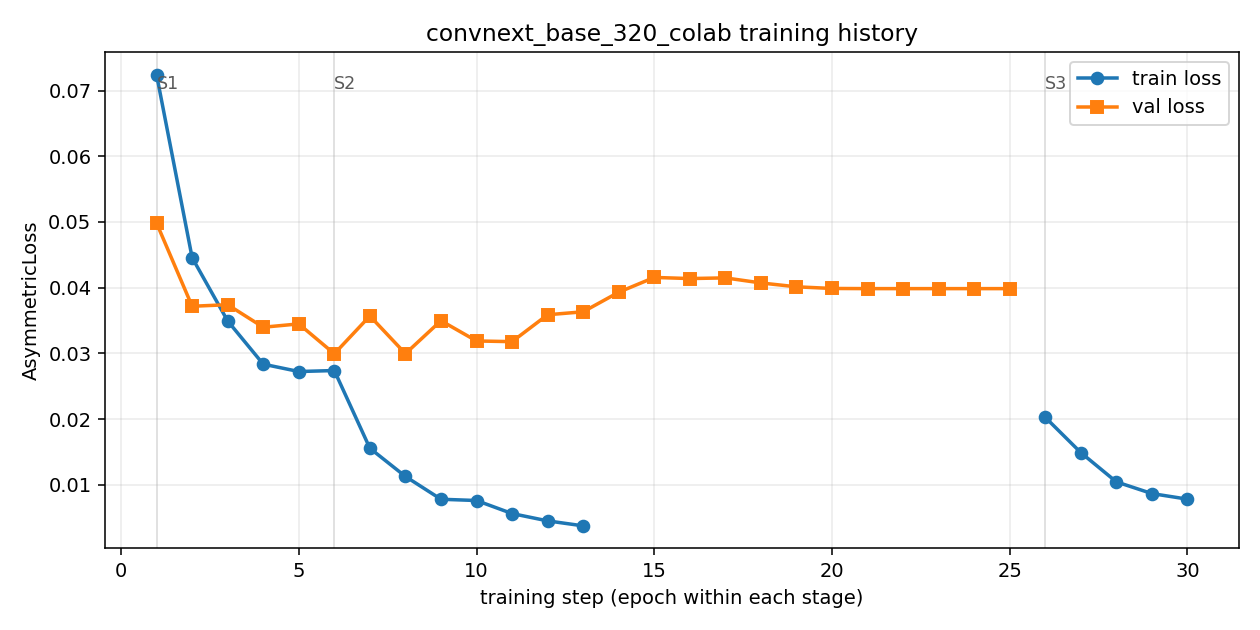

Saved figure: /content/drive/MyDrive/CV-Assignment2/image_classification/convnext_base_320_colab/figures/eval_ap_per_class.png


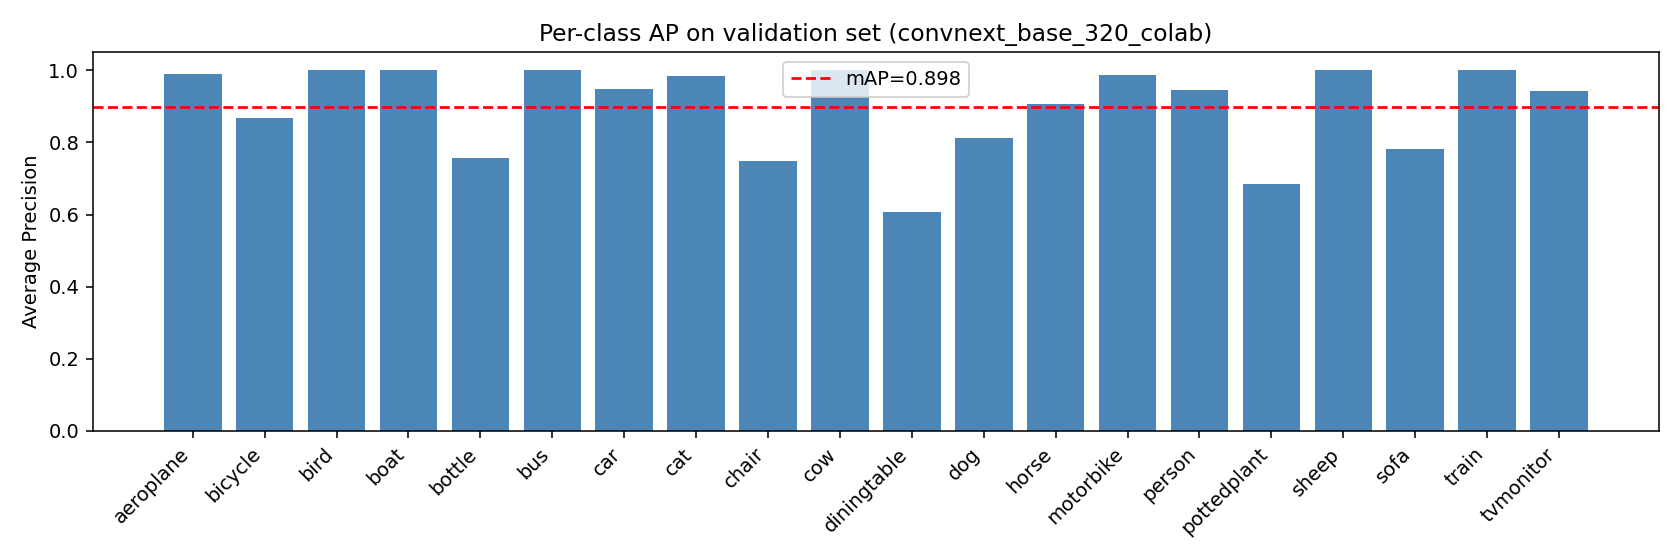

In [27]:
from IPython.display import Image as IPImage, display

if HISTORY_CSV.exists():
    history_df = pd.read_csv(HISTORY_CSV)
    plot_training_history(history_df, HISTORY_PLOT)
    display(IPImage(str(HISTORY_PLOT)))
else:
    print('Missing:', HISTORY_CSV)

if AP_CSV.exists():
    ap_df = pd.read_csv(AP_CSV)
    summary_map = None
    if SUMMARY_CSV.exists():
        summary_df = pd.read_csv(SUMMARY_CSV)
        if 'mAP' in summary_df.columns and len(summary_df) > 0:
            summary_map = float(summary_df.loc[0, 'mAP'])
    plot_ap_per_class(ap_df, AP_PLOT, map_score=summary_map)
    display(IPImage(str(AP_PLOT)))
else:
    print('Missing:', AP_CSV)


<!-- colab-cell-explain -->
## Recommended Settings for 749 Training Images

The dataset is small, so the best setting is usually not the largest possible model or batch size. Large batches make each epoch faster, but they reduce gradient noise and can make overfitting more visible. The goal is to use a batch size that fits comfortably while keeping validation performance stable.

### Suggested batch-size ranges

| Runtime / GPU | Tiny | Small | Base | Large |
|---|---:|---:|---:|---:|
| Local RTX 4060 Laptop 8 GB | 16 | 8 | 4 | 2 |
| Colab T4 16 GB | 32 | 12-16 | 6-8 | 2-4 |
| Colab L4 / V100 16-24 GB | 32-64 | 16-32 | 8-16 | 4-8 |
| Colab A100 40 GB | 64 | 32-64 | 16-32 | 8-16 |

Practical recommendation: use `convnext_small_320_colab` with batch size `16-32` first. Only try Base/Large after Small is submitted and you still have GPU budget.

### Suggested optimization ranges

| Parameter | Recommended range | Current default | Notes |
|---|---:|---:|---|
| `IMG_SIZE` | 320, optionally 384 on strong GPU | 320 | 384 may help small objects but is slower and can overfit. |
| `STAGE1_EPOCHS` | 3-5 | 5 | Head warm-up; longer rarely helps. |
| `STAGE1_LR` | 5e-4 to 1e-3 | 1e-3 | Safe because the backbone is frozen. |
| `STAGE2_EPOCHS` | 8-15, max 20 | 20 | Small/Base often overfit early; inspect `training_history.csv`. |
| `STAGE2_LR` | 3e-5 to 1e-4 | 1e-4 | Lower for Base/Large if validation loss rises quickly. |
| `STAGE3_EPOCHS` | 3-5 | 5 | Final all-data fit; keep short. |
| `STAGE3_LR` | 1e-5 to 5e-5 | 5e-5 | Use 1e-5 or 2e-5 for larger backbones. |
| `WEIGHT_DECAY` | 1e-4 to 5e-4 | 1e-4 | Increase if train loss falls but val loss worsens fast. |
| `VAL_SPLIT` | 0.15-0.25 | 0.2 | 0.2 is a good compromise for 749 images. |
| ASL `gamma_neg` | 2-4 | 4 | Lower if the model underpredicts rare classes. |
| ASL `clip` | 0.03-0.08 | 0.05 | Higher ignores more likely false negatives. |

### Current recommendation

For the current project state, keep `IMG_SIZE = 320`, `VAL_SPLIT = 0.2`, AsymmetricLoss, per-class thresholds and TTA. The strongest confirmed classifier is `convnext_small_320`, which achieved Kaggle display `0.44905` and adjusted classification Dice `0.89810`. On Colab, the next sensible runs are:

1. `convnext_small_320_colab`, batch size `16` or `32`, `STAGE2_EPOCHS = 12-20`.
2. `convnext_base_320_colab`, batch size `8` or `16`, `STAGE2_LR = 3e-5 to 1e-4`, stop if validation loss rises after only a few epochs.
3. `convnext_large_320_colab` only on A100/L4 with enough time; use a lower Stage 2 learning rate and short Stage 3.

Do not choose a very large batch only because memory allows it. For this small noisy dataset, validation mAP, per-class AP and Kaggle score are more important than raw training throughput.
